#### This project is an enhancement of the following project which is shared for reference during live session. All the modifications has been done based on this project and architechture. Please refer the following collab link for more details.

[Google Collab](https://colab.research.google.com/github/deep-learning-indaba/indaba-pracs-2019/blob/master/2a_deep_nets.ipynb#scrollTo=dYUH0qf8Dqkm)

#### This notebook specifically focused on the solutions of the following questions, which are asked to complete as per Assignment-1

- Question 1: During model training, evaluate the loss and accuracy on a validation set at the end of each epoch. Plot training and validation loss together and training and validation accuracy together. Using these plots, analyse the learning behaviour of the model and compare the validation performance with the final test performance.

- Question 2: Modify the neural network by introducing Dropout layers to improve generalisation. Compare the training and validation performance of the model before and after applying dropout, and discuss how dropout affects overfitting.

- Question 3: Extend the model by incorporating Batch Normalisation layers. Analyse their effect on convergence speed, training stability, and validation accuracy, and compare the results with the model without batch normalisation.

### Run the following to install all required libraries

In [ ]:
! pip install numpy matplotlib torch torchvision

In [113]:
# Import required libraries
# pip install torch torchvision torchaudio

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

In [114]:
# Set device to decide where computation happens

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device: ", device)

using device:  cpu


In [115]:
# Data Processing: Convert images to tensors and normalise them

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


In [116]:
# Load Fashion-MNIST Dataset

train_dataset = datasets.FashionMNIST(
    root= './data',
    train= True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root= './data',
    train= False,
    download=True,
    transform=transform
)

In [117]:
training_size = int (0.8 * len(train_dataset))
validation_size = len(train_dataset) - training_size

data_for_training, data_for_validation = torch.utils.data.random_split(
    train_dataset, [training_size, validation_size]
)

training_loader = torch.utils.data.DataLoader(
    data_for_training, batch_size=64, shuffle=True
)

validation_loader = torch.utils.data.DataLoader(
    data_for_validation, batch_size=64, shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=64, shuffle=True
)


### Q1: 
- (a) Evaluate the Training and Validation Losses and Accuracy
- (b) Plot the Training and Validation Losses and Accuracy
- (c) Evaluate the performance

Epoch 1/10 | Train Acc: 0.8066 | Val Acc: 0.8468
Epoch 2/10 | Train Acc: 0.8553 | Val Acc: 0.8667
Epoch 3/10 | Train Acc: 0.8700 | Val Acc: 0.8585
Epoch 4/10 | Train Acc: 0.8777 | Val Acc: 0.8743
Epoch 5/10 | Train Acc: 0.8847 | Val Acc: 0.8789
Epoch 6/10 | Train Acc: 0.8916 | Val Acc: 0.8759
Epoch 7/10 | Train Acc: 0.8965 | Val Acc: 0.8797
Epoch 8/10 | Train Acc: 0.8987 | Val Acc: 0.8854
Epoch 9/10 | Train Acc: 0.9031 | Val Acc: 0.8878
Epoch 10/10 | Train Acc: 0.9081 | Val Acc: 0.8869


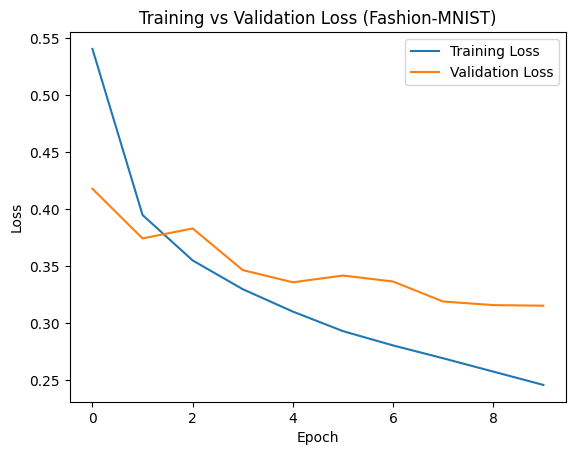

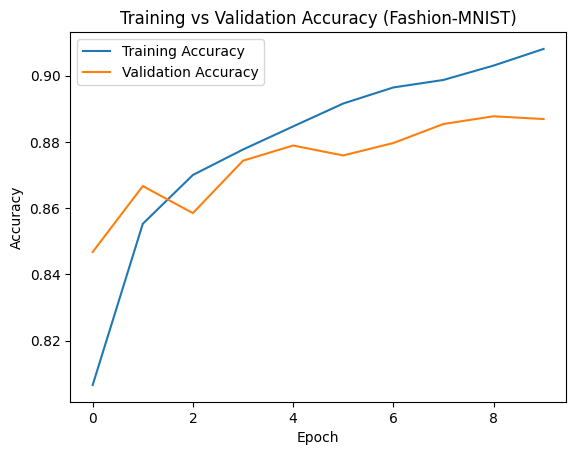

Final Test Accuracy: 0.8731


In [ ]:
# Define the Neural Network

class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x
    

# Define Loss function and Optimizer
model = SimpleNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)



# Training and Validation Loop

num_epochs = 10

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    # ---- Training ----
    model.train()
    correct, total, running_loss = 0, 0, 0.0

    for images, labels in training_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_losses.append(running_loss / len(training_loader))
    train_accuracies.append(correct / total)

    # ---- Validation ----
    model.eval()
    correct, total, running_loss = 0, 0, 0.0

    with torch.no_grad():
        for images, labels in validation_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_losses.append(running_loss / len(validation_loader))
    val_accuracies.append(correct / total)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Acc: {train_accuracies[-1]:.4f} | "
          f"Val Acc: {val_accuracies[-1]:.4f}")
    


# Plot Training vs Validation Loss

plt.figure()
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss (Fashion-MNIST)")
plt.show()



# Plot Training vs Validation Accuracy

plt.figure()
plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy (Fashion-MNIST)")
plt.show()

# Evaluate Final Test Performance

model.eval()
correct, total = 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = correct / total
print("Final Test Accuracy:", test_accuracy)

### Q2: 
- Introducing Dropout layers to the existing baseline network
- Compare the training and validation (Losses and Accuracy) of Dropout Model
- Evaluate Performance


Epoch 1/10 | Train Acc: 0.7053 | Val Acc: 0.8231
Epoch 2/10 | Train Acc: 0.7980 | Val Acc: 0.8477
Epoch 3/10 | Train Acc: 0.8118 | Val Acc: 0.8505
Epoch 4/10 | Train Acc: 0.8190 | Val Acc: 0.8512
Epoch 5/10 | Train Acc: 0.8260 | Val Acc: 0.8528
Epoch 6/10 | Train Acc: 0.8322 | Val Acc: 0.8618
Epoch 7/10 | Train Acc: 0.8338 | Val Acc: 0.8599
Epoch 8/10 | Train Acc: 0.8364 | Val Acc: 0.8672
Epoch 9/10 | Train Acc: 0.8399 | Val Acc: 0.8642
Epoch 10/10 | Train Acc: 0.8406 | Val Acc: 0.8667


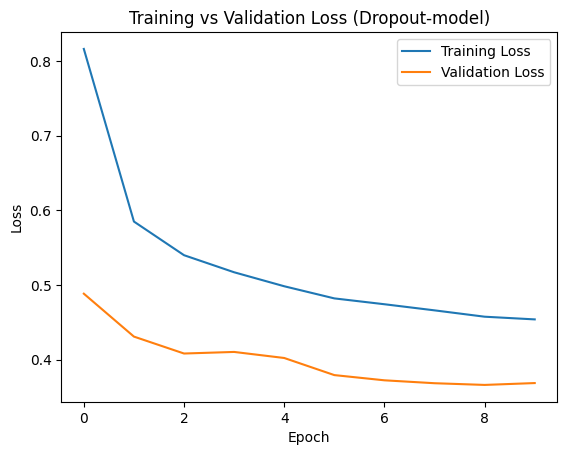

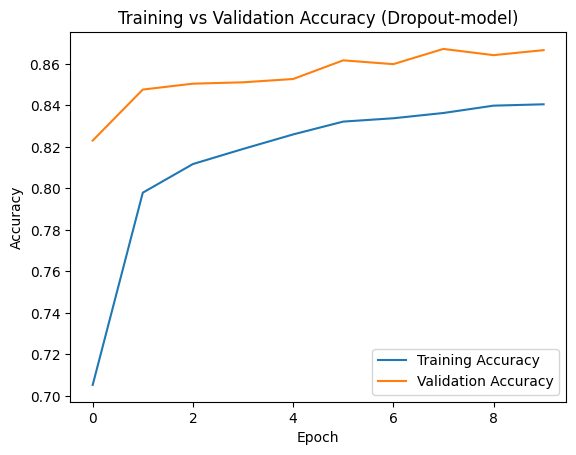

Final Test Accuracy: 0.852


In [ ]:
# Model with Dropout

class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.dropout1 = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(128, 64)
        self.dropout2 = nn.Dropout(p=0.5)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x
    

# Train the Dropout Model
modelDropout = SimpleNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelDropout.parameters(), lr=0.001)

# Training and Validation Loop on Dropout Model

num_epochs = 10
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    # ---- Training ----
    modelDropout.train()
    correct, total, running_loss = 0, 0, 0.0

    for images, labels in training_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = modelDropout(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_losses.append(running_loss / len(training_loader))
    train_accuracies.append(correct / total)

    # ---- Validation ----
    modelDropout.eval()
    correct, total, running_loss = 0, 0, 0.0

    with torch.no_grad():
        for images, labels in validation_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = modelDropout(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_losses.append(running_loss / len(validation_loader))
    val_accuracies.append(correct / total)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Acc: {train_accuracies[-1]:.4f} | "
          f"Val Acc: {val_accuracies[-1]:.4f}")
    



# Plot Training vs Validation Loss
plt.figure()
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss (Dropout-model)")
plt.show()

# Plot Training vs Validation Accuracy

plt.figure()
plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy (Dropout-model)")
plt.show()

# Evaluate Final Test Performance of Dropout Model

modelDropout.eval()
correct, total = 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = modelDropout(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = correct / total
print("Final Test Accuracy:", test_accuracy)

### Q3: 
- Incorporating Batch Normalisation layers and Evaluating the Performance

Epoch 1/10 | Train Acc: 0.8306 | Val Acc: 0.8667
Epoch 2/10 | Train Acc: 0.8709 | Val Acc: 0.8742
Epoch 3/10 | Train Acc: 0.8832 | Val Acc: 0.8849
Epoch 4/10 | Train Acc: 0.8914 | Val Acc: 0.8857
Epoch 5/10 | Train Acc: 0.8998 | Val Acc: 0.8916
Epoch 6/10 | Train Acc: 0.9048 | Val Acc: 0.8876
Epoch 7/10 | Train Acc: 0.9101 | Val Acc: 0.8910
Epoch 8/10 | Train Acc: 0.9146 | Val Acc: 0.8942
Epoch 9/10 | Train Acc: 0.9190 | Val Acc: 0.9011
Epoch 10/10 | Train Acc: 0.9215 | Val Acc: 0.8965


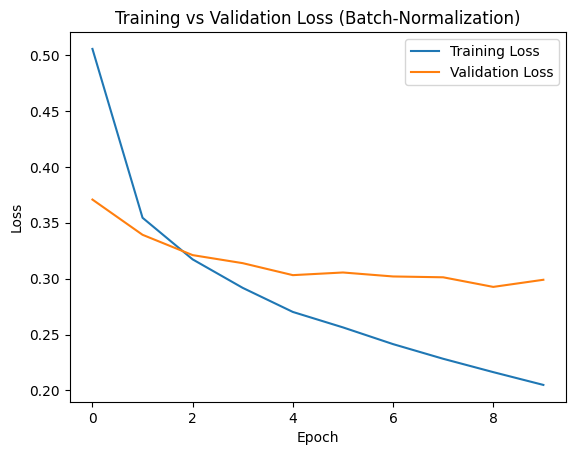

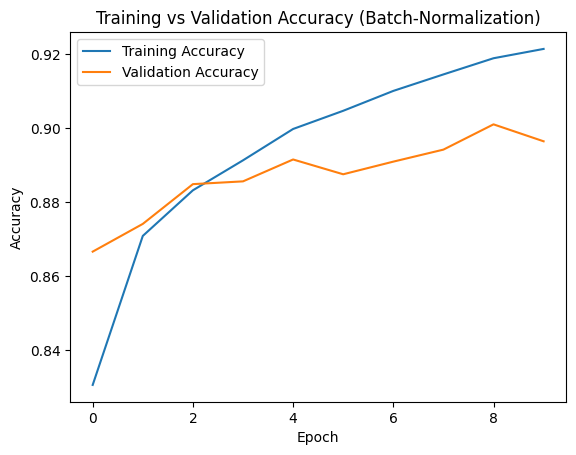

Final Test Accuracy: 0.8863


In [120]:
class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = torch.relu(self.bn1(self.fc1(x)))
        x = torch.relu(self.bn2(self.fc2(x)))
        x = self.fc3(x)
        return x
    


# Train the model with Batch normalization
batch_norm_model = SimpleNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(batch_norm_model.parameters(), lr=0.001)


# Training and Validation Batch normalization model

num_epochs = 10

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    # ---- Training ----
    batch_norm_model.train()
    correct, total, running_loss = 0, 0, 0.0

    for images, labels in training_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = batch_norm_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_losses.append(running_loss / len(training_loader))
    train_accuracies.append(correct / total)

    # ---- Validation ----
    batch_norm_model.eval()
    correct, total, running_loss = 0, 0, 0.0

    with torch.no_grad():
        for images, labels in validation_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = batch_norm_model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_losses.append(running_loss / len(validation_loader))
    val_accuracies.append(correct / total)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Acc: {train_accuracies[-1]:.4f} | "
          f"Val Acc: {val_accuracies[-1]:.4f}")
    

# Plot Training vs Validation Loss
plt.figure()
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss (Batch-Normalization)")
plt.show()

# Plot Training vs Validation Accuracy

plt.figure()
plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy (Batch-Normalization)")
plt.show()

# Evaluate Final Test Performance of Batch-Normalization Model

batch_norm_model.eval()
correct, total = 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = batch_norm_model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = correct / total
print("Final Test Accuracy:", test_accuracy)